In [1]:
# needed imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import cross_val_score

seed=1234

In [2]:
# dataset
import mnist_reader
X_train, y_train = mnist_reader.load_mnist('data/fashion', kind='train')
X_test, y_test = mnist_reader.load_mnist('data/fashion', kind='t10k')

(60000, 784)
(60000,)
(10000, 784)
(10000,)


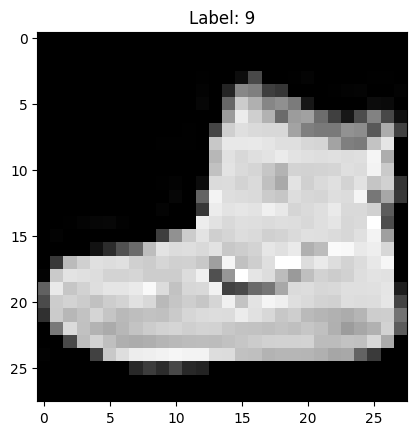

In [3]:
# looking at what we're dealing with

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.show()

In [4]:
# normalizing the data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# parameters i'm experimenting with
hidden_layer_sizes = [(128,), (256,), (128,64), (256,128)]

alpha = [0.001, 0.01]

learning_rate_init = [0.0001, 0.001, 0.01]

results = []

# how many configurations...
configs = list(product(
    hidden_layer_sizes,
    alpha,
    learning_rate_init
))

size = len(configs)
print(size)

24


In [6]:
# creating validation set
X_full_train = X_train
y_full_train = y_train

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.2,
    random_state=42,
    stratify=y_full_train
)

In [7]:
# making this beautiful table
for hidden_layers, alpha, lr in configs:

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation='relu',
        alpha=alpha,
        learning_rate_init=lr,
        max_iter=50,
        random_state=42
    )

    model.fit(X_train_split, y_train_split)

    train = model.score(X_train_split, y_train_split)
    val = model.score(X_val, y_val)

    results.append({
        "Hidden Layers": str(hidden_layers),
        "Alpha": alpha,
        "Learning Rate": lr,
        "Train accuracy": train,
        "Val accuracy": val,
    })

C:\Users\sbsri\Documents\cs178\palab\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\sbsri\Documents\cs178\palab\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\sbsri\Documents\cs178\palab\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\sbsri\Documents\cs178\palab\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\sbsri\Documents\cs1

In [12]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Val accuracy", ascending=False)
results_df

,Hidden Layers,Alpha,Learning Rate,Train accuracy,Val accuracy
9,"(256,)",0.010,0.0001,0.966437,0.903167
6,"(256,)",0.001,0.0001,0.966667,0.902917
18,"(256, 128)",0.001,0.0001,0.985354,0.902083
21,"(256, 128)",0.010,0.0001,0.984458,0.901417
22,"(256, 128)",0.010,0.0010,0.992771,0.899917
7,"(256,)",0.001,0.0010,0.994771,0.897417
16,"(128, 64)",0.010,0.0010,0.988896,0.897333
3,"(128,)",0.010,0.0001,0.947583,0.896750
0,"(128,)",0.001,0.0001,0.948167,0.896583
15,"(128, 64)",0.010,0.0001,0.959104,0.896083
